In [1]:
import cafe

cafe.logger.setLevel("DEBUG")

cafe.settings.backend = "conda"

[10/24/2025 12:39:07] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

In [2]:
fadata = cafe.data.read_h5ad("../../tests/data/pancrease_scvelo_500_fadata.h5ad")
fadata.add_prior_information(start_cell="cell_000")

fadata

                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                        
                      DEBUG    unserialize trajectory dict: 'ref'                                                                                                                                       
                      DEBUG    parse 'MilestoneWrapper' object for ref                                                                                                                              

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe', 'id'
    obsm: 'X_pca', 'X_umap'
    layers: 'count', 'expression', 'spliced', 'unspliced'

In [ ]:
parameters = {}
# note:  need mannually add model file 
# from: /root/PyCode/scRNA/CellFateExplorer/CellFateExplorer/method_docker/cytotrace2_py/resources
# to: /root/miniconda3/envs/cytotrace2/lib/python3.10/site-packages/cytotrace2_py/resources 
method = cafe.method.FateMethod(method_name="cytotrace2") 
# method = cafe.method.FateMethod(method_name="velovi")
# method = cafe.method.FateMethod(method_name="pyrovelocity")
# method = cafe.method.FateMethod(method_name="unitvelo")
# method = cafe.method.FateMethod(method_name="celldancer")
method.infer_trajectory(fadata, parameters)

[10/24/2025 12:41:59] DEBUG    CondaBackend __init__                                                                                                                                                    
[10/24/2025 12:42:01] DEBUG    Conda environment 'cytotrace2' found.                                                                                                                                    
[10/24/2025 12:42:02] DEBUG    Conda environment 'cytotrace2' is available: Python 3.10.18                                                                                                              
                      DEBUG    Loaded function 'cytotrace2': <function cytotrace2 at 0x716501f5c550>                                                                                                    
                      INFO     method backend loaded: CondaBackend: cytotrace2 in conda env 'cytotrace2'                                                                                            

[10/24/2025 12:49:21] DEBUG    extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                              
                      DEBUG    calculate new trajectory embedding for model_name:20251024_124202__cytotrace2-conda__NNGJ6E72DT, basis:X_umap.                                                           
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
[10/24/2025 12:49:22] DEBUG    add waypoints shape is (201, 500) for '20251024_124202__cytotrace2-conda__NNGJ6E72DT', finished!                                                                     

<Axes: title={'center': 'cytotrace2-conda(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>

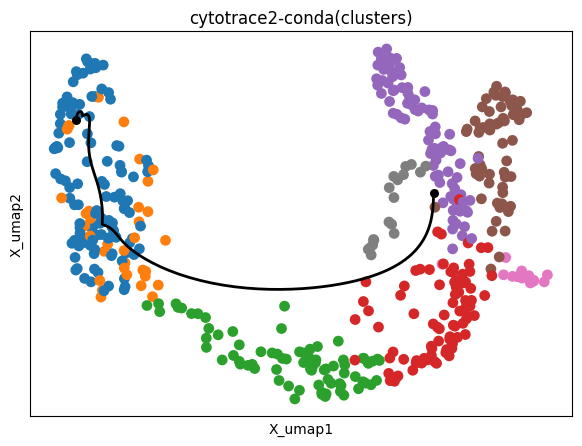

In [5]:
cafe.plot.plot_trajectory(fadata, color="clusters")

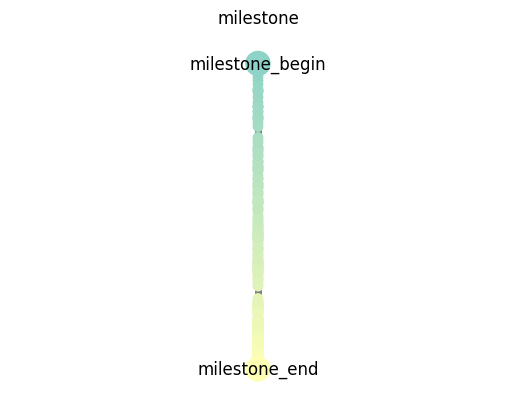

In [6]:
cafe.plot.plot_graph(fadata)